In [ ]:
print("Step 1: Uploading and Reading the Dataset")

from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, parse_dates=['date'], index_col='date')
df = df.asfreq('D')  # Ensure daily frequency

print(df.info())
df.head()


Step 1: Uploading and Reading the Dataset


Saving weather_data.csv to weather_data (2).csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Freq: D
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB
None


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


Step 2: Visualizing and Checking Stationarity


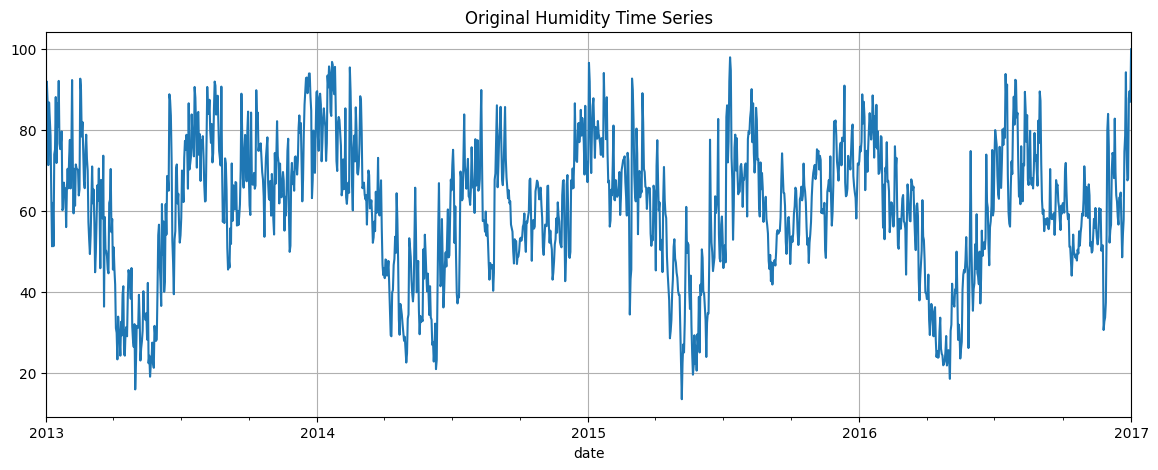

ADF Statistic: -3.675576919163344
p-value: 0.004470100478130688
✅ Stationary


In [ ]:
print("Step 2: Visualizing and Checking Stationarity")

import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Plot humidity
plt.figure(figsize=(14,5))
df['humidity'].plot(title='Original Humidity Time Series')
plt.grid(True)
plt.show()

# ADF Test
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("✅ Stationary")
    else:
        print("❌ Not Stationary")

adf_test(df['humidity'])


Step 3: Making the Data Stationary (Differencing)


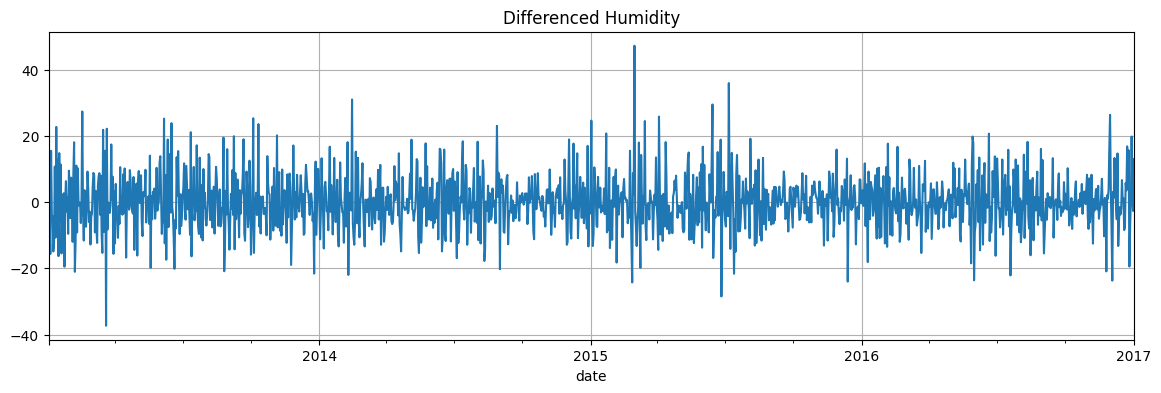

ADF Statistic: -12.683532100905559
p-value: 1.1729233587043616e-23
✅ Stationary


In [ ]:
print("Step 3: Making the Data Stationary (Differencing)")

df['humidity_diff'] = df['humidity'].diff()
df['humidity_diff'].dropna().plot(figsize=(14, 4), title="Differenced Humidity")
plt.grid(True)
plt.show()

# ADF test again
adf_test(df['humidity_diff'])


Step 4: ACF and PACF Plots


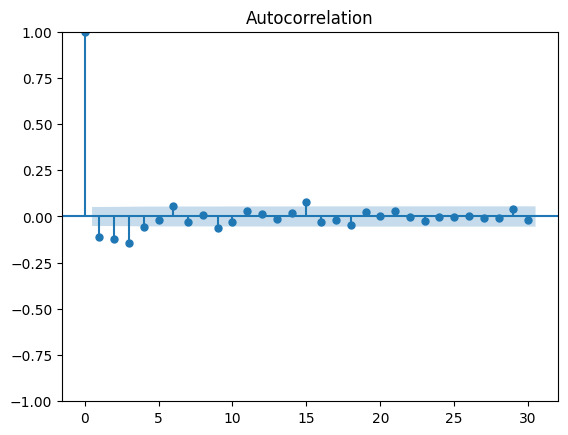

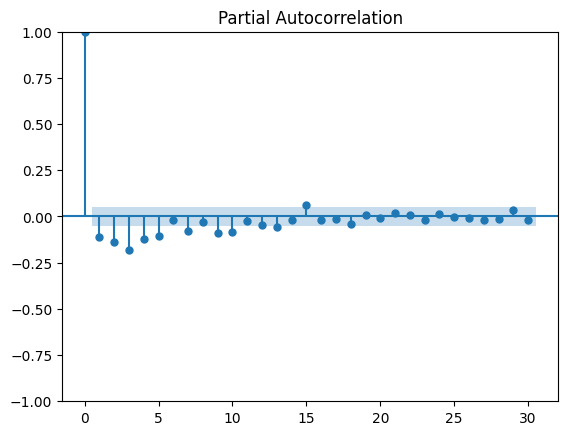

In [ ]:
print("Step 4: ACF and PACF Plots")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['humidity_diff'].dropna(), lags=30)
plot_pacf(df['humidity_diff'].dropna(), lags=30)
plt.show()


Step 5: Fitting ARIMA Model
                               SARIMAX Results                                
Dep. Variable:               humidity   No. Observations:                 1462
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -5077.015
Date:                Tue, 27 May 2025   AIC                          10164.029
Time:                        16:00:55   BIC                          10190.464
Sample:                    01-01-2013   HQIC                         10173.890
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9452      0.291      3.244      0.001       0.374       1.516
ar.L2         -0.2744      0.185     -1.480      0.139      -0.638       0.089
ma.L1         -1.1541   

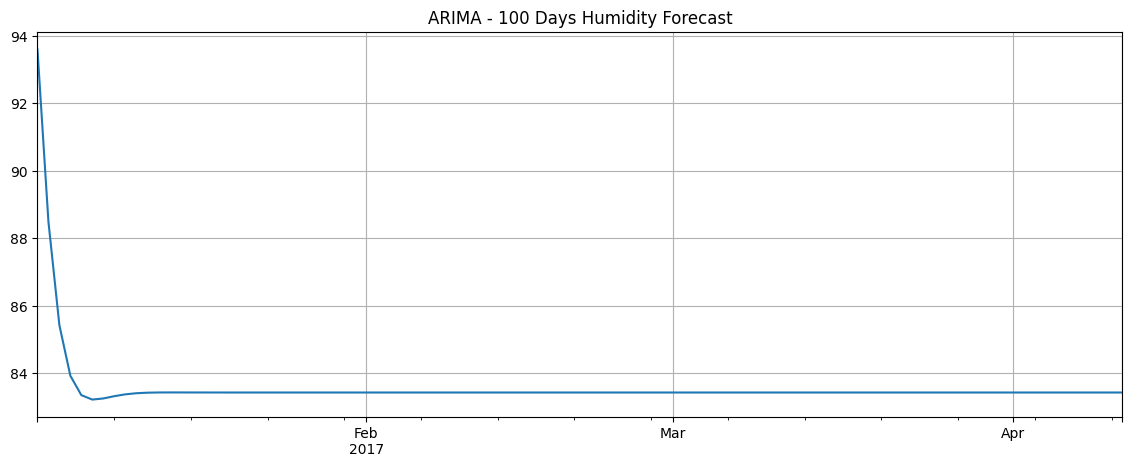

In [ ]:
print("Step 5: Fitting ARIMA Model")

from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA (adjust order after checking ACF/PACF)
model_arima = ARIMA(df['humidity'], order=(2,1,2))
result_arima = model_arima.fit()
print(result_arima.summary())

# Forecast next 100 days
forecast_arima = result_arima.forecast(steps=100)
forecast_arima.plot(title='ARIMA - 100 Days Humidity Forecast', figsize=(14,5))
plt.grid(True)
plt.show()


Step 6: Fitting SARIMA Model
                                      SARIMAX Results                                       
Dep. Variable:                             humidity   No. Observations:                 1462
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -5001.358
Date:                              Tue, 27 May 2025   AIC                          10016.716
Time:                                      16:01:20   BIC                          10053.594
Sample:                                  01-01-2013   HQIC                         10030.485
                                       - 01-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8699      0.272      3.201      0.001       0.337   

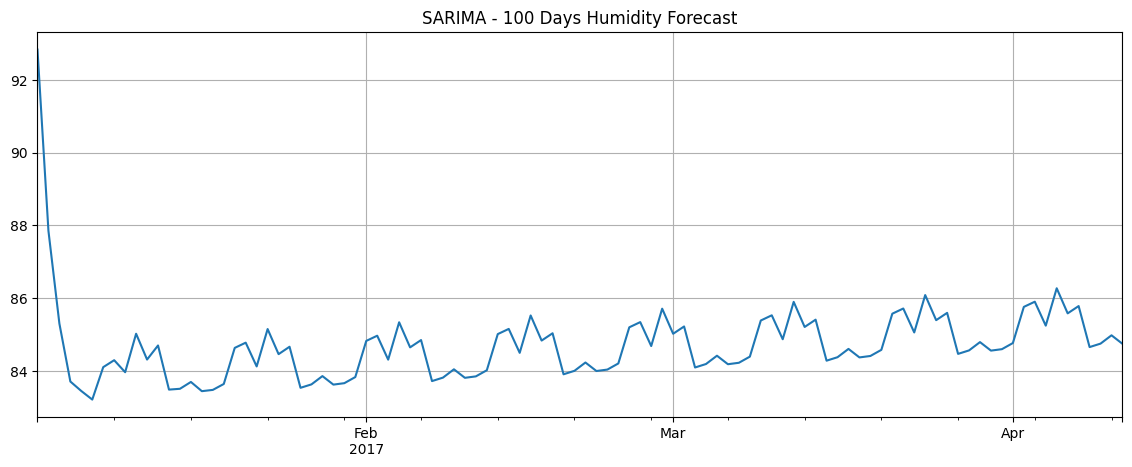

In [ ]:
print("Step 6: Fitting SARIMA Model")

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(df['humidity'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12),  # monthly seasonality
                       enforce_stationarity=False,
                       enforce_invertibility=False)

result_sarima = model_sarima.fit()
print(result_sarima.summary())

# Forecast next 100 days
forecast_sarima = result_sarima.forecast(steps=100)
forecast_sarima.plot(title='SARIMA - 100 Days Humidity Forecast', figsize=(14,5))
plt.grid(True)
plt.show()


In [ ]:
print("Step 7: Installing and Importing Prophet")

# Install Prophet (only needed once)
!pip install prophet

# Import
from prophet import Prophet


Step 7: Installing and Importing Prophet
